In [1]:
import jax
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa: F401
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import matplotlib.animation as animation

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from kandel.sim_api.gymnasium import evaluate
from kandel.utility.checkpoint_loader import load_environment, load_policy

plt.style.use(["science", "grid"])

In [2]:
import pathlib

current_dir = pathlib.Path().parent.resolve()
new_folder_path = current_dir / "plots"
new_folder_path.mkdir(parents=True, exist_ok=True)

## Run gymnasium interaction

In [3]:
def evaluate_checkpoint(
    checkpoint_directory, checkpoint, policy_id, episode_length, seed
):
    env, info = load_environment(
        checkpoint_directory=checkpoint_directory,
        checkpoint=checkpoint,
    )
    policy, policy_params = load_policy(
        checkpoint_directory=checkpoint_directory,
        checkpoint=checkpoint,
        policy_id=policy_id,
    )

    forward_fcn = jax.jit(policy.forward)
    update_fcn = jax.jit(policy.update)
    reset_fcn = policy.reset

    rng = jax.random.key(seed)
    rng_reset, rng_eval = jax.random.split(rng)

    policy_params = reset_fcn(policy_params, rng_reset)

    rewards, _, _, weight_history, reward_history = evaluate(
        random_key=rng_eval,
        envs=env,
        forward_fcn=forward_fcn,
        update_fcn=update_fcn,
        policy_params=policy_params,
        episode_steps=episode_length,
        environment_interval=info["step_interval"],
        hebbian_update_interval=info["update_interval"],
        record_policy=True,
        record_stepwise_rewards=True,
    )

    print(rewards)

    env.close()

    return reward_history, weight_history

In [4]:
def compute_euclidian_distance(weight_history):
    euclidian_history = []
    layers = weight_history[0]["kernel_params"].keys()

    for t in range(len(weight_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = weight_history[t]["kernel_params"][layer]["W"]
            params_t2 = weight_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        euclidian_history.append(mse)
    euclidian_history = np.array(euclidian_history)
    return euclidian_history

In [5]:
def select_random_weights(weight_history, num_neurons=10, selection_seed=0):
    np.random.seed(selection_seed)
    layers = weight_history[0]["kernel_params"].keys()

    indices = []
    for _ in range(num_neurons):
        selected_layer = np.random.choice(list(layers))
        array_shape = weight_history[0]["kernel_params"][selected_layer][
            "W"
        ].shape

        # Random indices
        ind_1 = np.random.randint(0, array_shape[0] - 1)
        ind_2 = np.random.randint(0, array_shape[1] - 1)

        indices.append((selected_layer, ind_1, ind_2))

    neuron_ts = []
    for i in indices:
        neuron_signal = []
        for t in range(len(weight_history)):
            neuron_signal.append(
                weight_history[t]["kernel_params"][i[0]]["W"][i[1], i[2]]
            )

        neuron_ts.append(neuron_signal)

    neuron_ts = np.array(neuron_ts)
    return neuron_ts

In [6]:
def compute_pca_2d(weight_history):
    pca = PCA(n_components=2)
    scaler = StandardScaler()

    flat_hist = []
    for t in range(len(weight_history)):
        params = weight_history[t]["kernel_params"]["layer_0"]["W"].flatten()
        flat_hist.append(params)

    flat_hist = np.array(flat_hist)
    flat_hist = scaler.fit_transform(flat_hist)
    weights_pca = pca.fit_transform(flat_hist)

    return weights_pca

## Plot  weight dynamics

In [7]:
paths = [
    "/home/alexanderdittrich/Downloads/ocarina/250419013941-halfcheetah-mlp-hebbian-adaptive-es-6/",
    "/home/alexanderdittrich/Downloads/ocarina/250418093513-halfcheetah-mlp-hebbian-adaptive-es-4/",
    "/home/alexanderdittrich/Downloads/ocarina/250420010524-halfcheetah-mlp-hebbian-adaptive-es-15",
]  # with WS

# paths = [
#     # "/home/lis/Downloads/saxophone/241216075908-halfcheetah-mlp-simple-es-5/",
#     # "/home/lis/Downloads/saxophone/241213172232-halfcheetah-mlp-hebbian-simple-es-12/",
#     "/home/lis/Downloads/tabla/250408221532-halfcheetah-mlp-hebbian-adaptive-es-3/",
#     "/home/lis/Downloads/tabla/250408222024-halfcheetah-mlp-hebbian-adaptive-es-2/",
#     "/home/lis/Downloads/tabla/250409093243-halfcheetah-mlp-hebbian-adaptive-es-3/"
# ] # without WS

checkpoint = 999
policy_id = 0
seed = 11
episode_length = 200

In [8]:
weight_histories = []
euclidian_histories = []
single_weight_histories = []
pca_histories = []
for path in paths:
    reward_history, weight_history = evaluate_checkpoint(
        path, checkpoint, policy_id, episode_length, seed
    )
    euclidian_history = compute_euclidian_distance(weight_history)
    single_weight_history = select_random_weights(
        weight_history, selection_seed=5
    )
    pca_history = compute_pca_2d(weight_history)

    weight_histories.append(weight_history)
    euclidian_histories.append(euclidian_history)
    single_weight_histories.append(single_weight_history)
    pca_histories.append(pca_history)

ERROR:2025-09-22 00:58:30,438:jax._src.xla_bridge:502: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 500, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN
ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling j

[970.8908]
[1309.4117]
[1285.0371]


/tmp/ipykernel_5425/3835302462.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


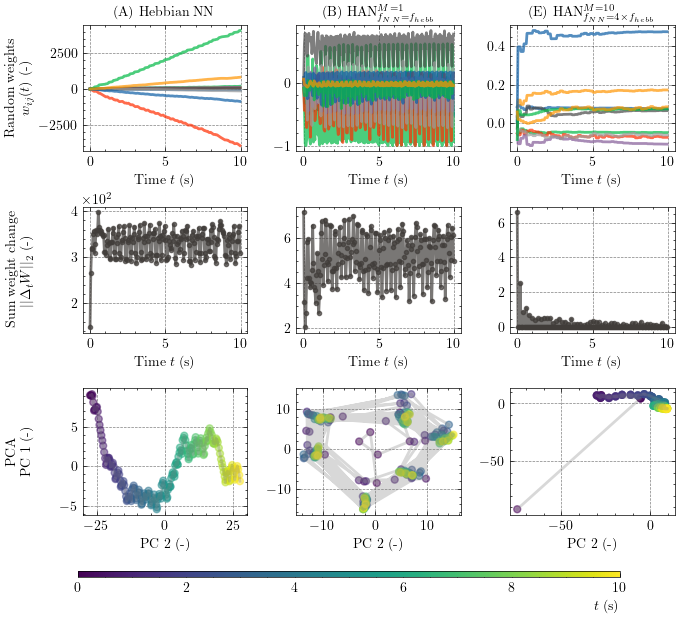

In [10]:
fig, axs = plt.subplots(3, 3, figsize=(7.0, 7.5))

# Layout axis labels
ylabels = [
    "Random weights\n $w_{ij}(t)$ (-)",
    "Sum weight change\n" + "$||\\Delta_t W ||_2$ (-)",
    "PCA\n PC 1 (-)",
]
for i, ylabel in enumerate(ylabels):
    axs[i, 0].set_ylabel(ylabel, fontsize=10)

xlabels = [
    r"(A) Hebbian NN",
    r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$",
    r"(E) HAN$^{M=10}_{f_{NN}=4 \times f_{hebb}}$",
]

# xlabels = [
#     r"(A) Hebbian NN without MN""\n""without MA $M=1$, ${f_{NN}=f_{hebb}}$",
#     r"(A) Hebbian NN without MN""\n""with MA $M=10$, ${f_{NN}=f_{hebb}}$",
#     r"(A) Hebbian NN without MN""\n""with MA $M=10$, ${f_{NN}>f_{hebb}}$",
# ]

for i, xlabel in enumerate(xlabels):
    axs[0, i].set_title(xlabel, fontsize=10)

for i in range(3):
    axs[0, i].set_xlabel("Time $t$ (s)")
    axs[1, i].set_xlabel("Time $t$ (s)")
    axs[2, i].set_xlabel("PC 2 (-)")


t = np.arange(episode_length) * 0.05

for i, single_weight in enumerate(single_weight_histories):
    axs[0, i].plot(t, single_weight.T[:-1], alpha=0.7, linewidth=2)

for i, euc_hist in enumerate(euclidian_histories):
    axs[1, i].plot(
        t,
        euc_hist,
        marker=".",
        color="#413D3A",
        alpha=0.7,
        linewidth=2,
    )
    axs[1, i].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

t = np.arange(episode_length + 1) * 0.05
cmap = cm.viridis
norm = mcolors.Normalize(vmin=t[0], vmax=t[-1])

for i, pca_hist in enumerate(pca_histories):
    axs[2, i].plot(
        pca_hist[:, 0],
        pca_hist[:, 1],
        # pca_history[:, 2],
        color="grey",
        alpha=0.3,
        linewidth=2,
    )

    axs[2, i].scatter(
        pca_hist[:, 0],
        pca_hist[:, 1],
        # pca_history[t, 2],
        alpha=0.5,
        c=t,
        cmap=cm.viridis,
        s=25,
    )

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# cbar = fig.colorbar(sm, ax=axs[2, -1])
# cbar.set_label("Time (s)", loc="top")

cbar = fig.colorbar(
    sm,
    ax=axs,
    orientation="horizontal",
    # fraction=0.01,
    pad=-0.45,
    aspect=80,
)
cbar.set_label("$t$ (s)", loc="right")

# Further layouting
for ax in axs.flatten():
    ax.grid(True)

fig.align_titles()
fig.align_ylabels()

fig.tight_layout()
fig.savefig("plots/cheetah_weight_dynamics.svg", transparent=True)
fig.savefig("plots/cheetah_weight_dynamics.pdf", transparent=True)

# fig.savefig("plots/cheetah_weight_dynamics_wo_ws.svg", transparent=True)
# fig.savefig("plots/cheetah_weight_dynamics_wo_ws.pdf", transparent=True)

plt.show()